In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
df = pd.read_csv("Sales Dataset.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [10]:
sales_data = df['Item_Outlet_Sales'].astype(float)

In [11]:
sales_data.index = pd.RangeIndex(start=1, stop=len(sales_data)+1, step=1)

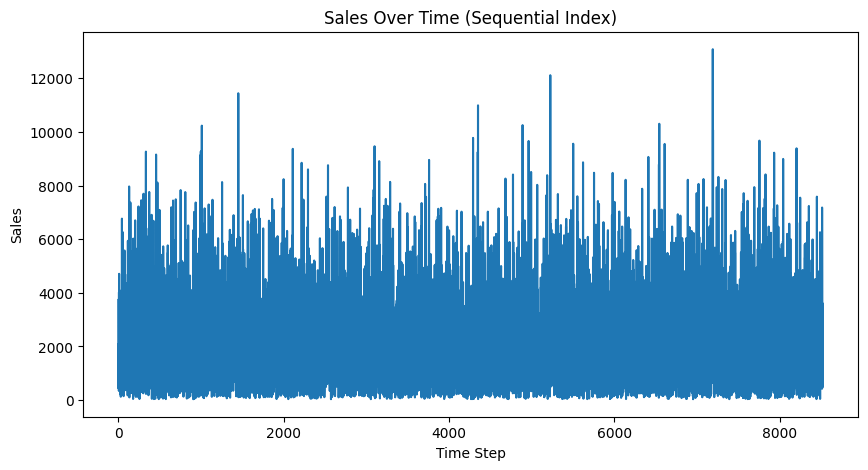

In [12]:
plt.figure(figsize=(10,5))
plt.plot(sales_data)
plt.title("Sales Over Time (Sequential Index)")
plt.xlabel("Time Step")
plt.ylabel("Sales")
plt.show()

In [13]:
result = adfuller(sales_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -91.76808169582387
p-value: 0.0


In [14]:
train_size = int(len(sales_data) * 0.8)

train = sales_data[:train_size]
test = sales_data[train_size:]

In [15]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      Item_Outlet_Sales   No. Observations:                 6816
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -60367.731
Date:                Sun, 01 Mar 2026   AIC                         120741.462
Time:                        18:03:39   BIC                         120761.943
Sample:                             0   HQIC                        120748.529
                               - 6816                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0031      0.012      0.250      0.803      -0.021       0.027
ma.L1         -1.0000      0.008   -131.788      0.000      -1.015      -0.985
sigma2      2.891e+06   4.55e+04     63.485      0.0

In [16]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

In [17]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1363.785486929112
RMSE: 1731.6910323676966


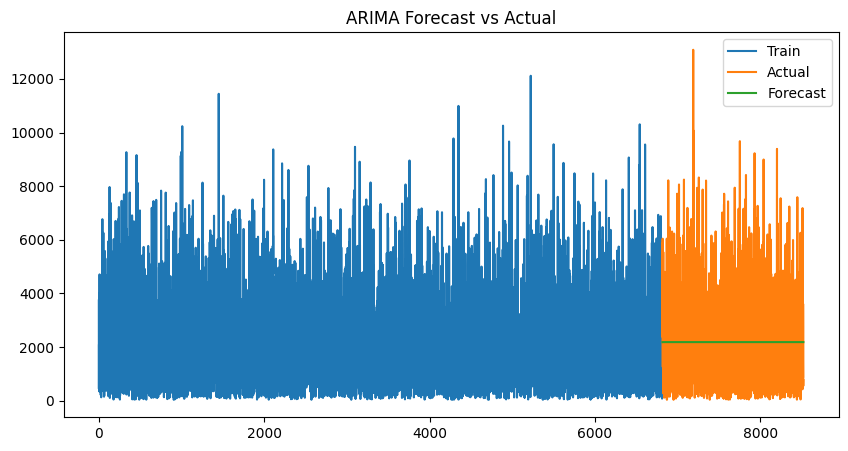

In [18]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [19]:
future_steps = 10

future_forecast = model_fit.forecast(steps=future_steps)

print("Future Sales Prediction:")
print(future_forecast)

Future Sales Prediction:
6817    2182.274884
6818    2184.389819
6819    2184.396300
6820    2184.396320
6821    2184.396320
6822    2184.396320
6823    2184.396320
6824    2184.396320
6825    2184.396320
6826    2184.396320
Name: predicted_mean, dtype: float64
